In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

### Load and understand the data

In [8]:
df = pd.read_csv('../data/raw/raw_analyst_ratings.csv', index_col=0)

# Remove timezone offset (-04:00, -05:00, etc.)
df['date'] = df['date'].str.replace(r'-\d{2}:\d{2}$', '', regex=True)

# Now convert to datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

print(f"Dataset shape: {df.shape}")
print(f"\nColumn names: {df.columns.tolist()}")
print(f"\nData types:")
print(df.dtypes)

Dataset shape: (1407328, 5)

Column names: ['headline', 'url', 'publisher', 'date', 'stock']

Data types:
headline                str
url                     str
publisher               str
date         datetime64[us]
stock                   str
dtype: object


Sample First 3 rows

In [9]:
df.head(3)

,headline,url,publisher,date,stock
0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54,A
1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20,A
2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07,A


Check for missing values

In [10]:
print(df.isnull().sum())

headline     0
url          0
publisher    0
date         0
stock        0
dtype: int64


### Headline Character Count Distribution

In [11]:
# Create a new column with headline length
df['headline_length'] = df['headline'].str.len()

# Basic statistics
print("=== HEADLINE LENGTH STATISTICS ===")
print(f"Minimum length: {df['headline_length'].min()} characters")
print(f"Maximum length: {df['headline_length'].max()} characters")
print(f"Average length: {df['headline_length'].mean():.1f} characters")
print(f"Median length: {df['headline_length'].median():.1f} characters")
print(f"Standard deviation: {df['headline_length'].std():.1f}")

=== HEADLINE LENGTH STATISTICS ===
Minimum length: 3 characters
Maximum length: 512 characters
Average length: 73.1 characters
Median length: 64.0 characters
Standard deviation: 40.7


Percentiles (shows distribution)

In [12]:
print(f"\nPercentiles:")
print(f"25% of headlines are shorter than: {df['headline_length'].quantile(0.25)} chars")
print(f"75% of headlines are shorter than: {df['headline_length'].quantile(0.75)} chars")
print(f"90% of headlines are shorter than: {df['headline_length'].quantile(0.90)} chars")


Percentiles:
25% of headlines are shorter than: 47.0 chars
75% of headlines are shorter than: 87.0 chars
90% of headlines are shorter than: 117.0 chars


In [13]:
shortest_idx = df['headline_length'].idxmin()
longest_idx = df['headline_length'].idxmax()

print(f"\n Shortest headline ({df['headline_length'].min()} chars):")
print(f"   {df.loc[shortest_idx, 'headline']}")

print(f"\n Longest headline ({df['headline_length'].max()} chars):")
print(f"   {df.loc[longest_idx, 'headline'][:200]}...")


 Shortest headline (3 chars):
   SPY

 Longest headline (512 chars):
   JinkoSolar Tiger Pro Series Receives World's First IEC 61701 Ed. 3 (FDIS) Certification for Salt Mist Corrosion Standards JinkoSolar Holding Co., Ltd. (the "Company," or "JinkoSolar") (NYSE:JKS), one ...


Visualizations

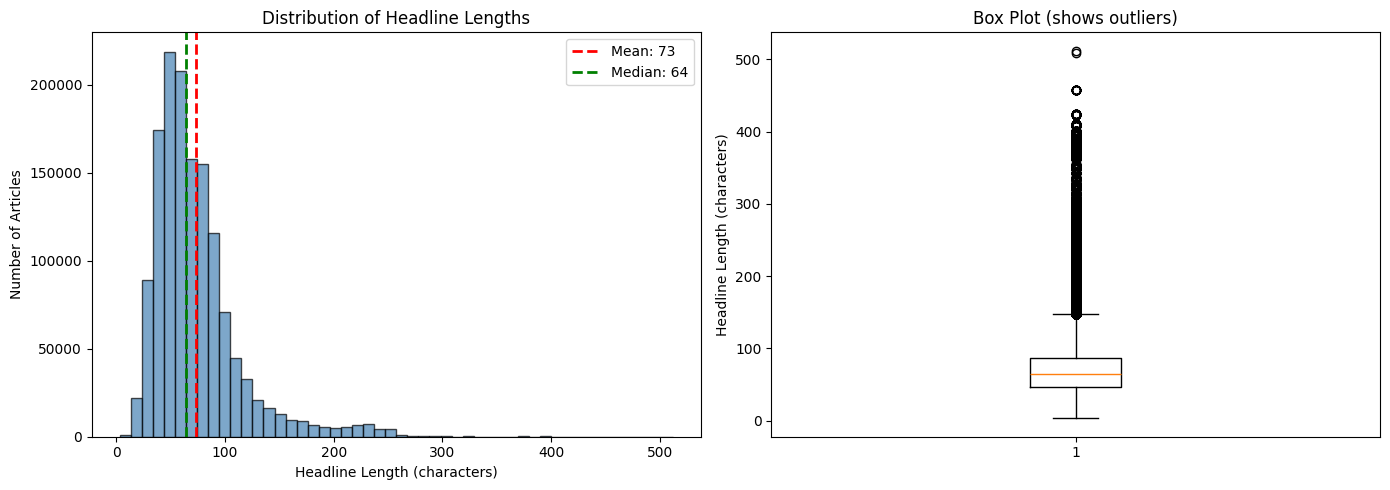

In [14]:
# Visualization 1: Histogram
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['headline_length'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(df['headline_length'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["headline_length"].mean():.0f}')
axes[0].axvline(df['headline_length'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df["headline_length"].median():.0f}')
axes[0].set_xlabel('Headline Length (characters)')
axes[0].set_ylabel('Number of Articles')
axes[0].set_title('Distribution of Headline Lengths')
axes[0].legend()

# Box plot
axes[1].boxplot(df['headline_length'], vert=True)
axes[1].set_ylabel('Headline Length (characters)')
axes[1].set_title('Box Plot (shows outliers)')

plt.tight_layout()
plt.show()

### Count Articles per Publisher

In [15]:
# Count articles per publisher
publisher_counts = df['publisher'].value_counts()

print("=== PUBLISHER ACTIVITY ANALYSIS ===")
print(f"Total unique publishers: {len(publisher_counts)}")
print(f"Total articles: {len(df):,}")
print(f"\nTop 10 Most Active Publishers:")
print(publisher_counts.head(10))

=== PUBLISHER ACTIVITY ANALYSIS ===
Total unique publishers: 1034
Total articles: 1,407,328

Top 10 Most Active Publishers:
publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64


Calculate market share

In [17]:
# Calculate market share
print(f"\n=== TOP 5 PUBLISHERS MARKET SHARE ===")
top5 = publisher_counts.head(5)
for publisher, count in top5.items():
    pct = (count / len(df)) * 100
    print(f"{publisher}: {count:,} articles ({pct:.1f}% of all news)")


=== TOP 5 PUBLISHERS MARKET SHARE ===
Paul Quintaro: 228,373 articles (16.2% of all news)
Lisa Levin: 186,979 articles (13.3% of all news)
Benzinga Newsdesk: 150,484 articles (10.7% of all news)
Charles Gross: 96,732 articles (6.9% of all news)
Monica Gerson: 82,380 articles (5.9% of all news)


In [18]:
# Check concentration (do few publishers dominate?)
top1_pct = (publisher_counts.iloc[0] / len(df)) * 100
top5_pct = (publisher_counts.head(5).sum() / len(df)) * 100
top10_pct = (publisher_counts.head(10).sum() / len(df)) * 100

print(f"\n=== PUBLISHER CONCENTRATION ===")
print(f"Top 1 publisher covers: {top1_pct:.1f}% of all news")
print(f"Top 5 publishers cover: {top5_pct:.1f}% of all news")
print(f"Top 10 publishers cover: {top10_pct:.1f}% of all news")


=== PUBLISHER CONCENTRATION ===
Top 1 publisher covers: 16.2% of all news
Top 5 publishers cover: 52.9% of all news
Top 10 publishers cover: 66.5% of all news


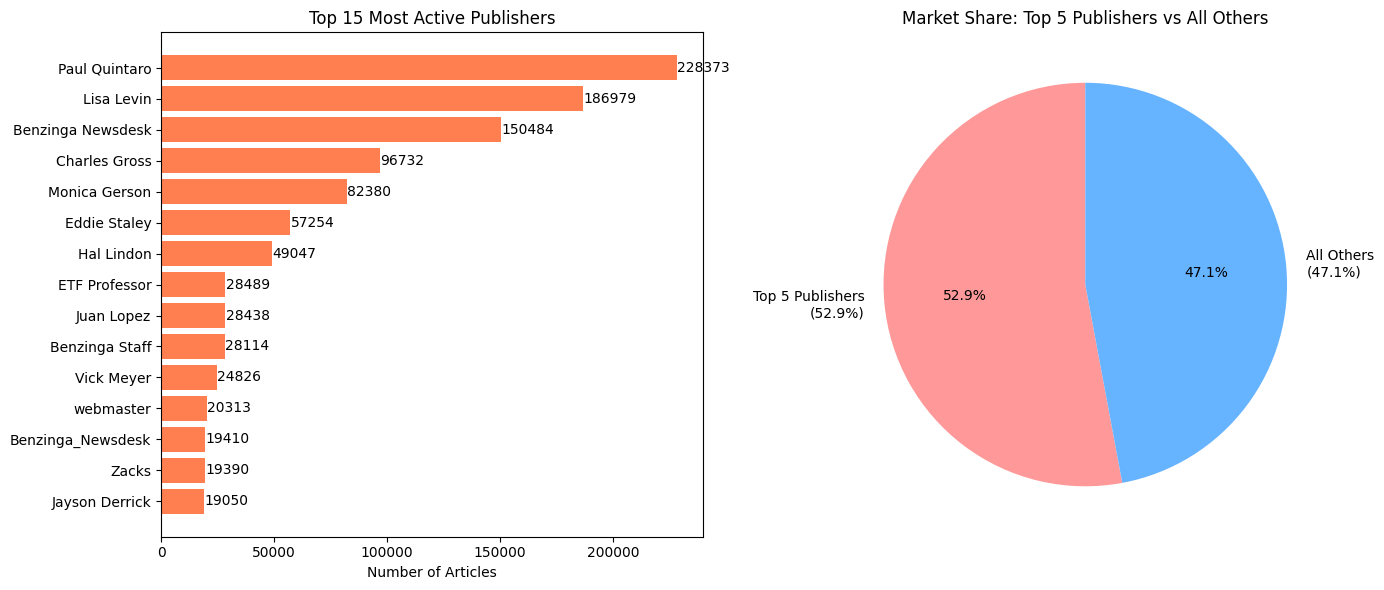

In [19]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar chart - Top 15 publishers
top_publishers = publisher_counts.head(15)
axes[0].barh(range(len(top_publishers)), top_publishers.values, color='coral')
axes[0].set_yticks(range(len(top_publishers)))
axes[0].set_yticklabels(top_publishers.index)
axes[0].set_xlabel('Number of Articles')
axes[0].set_title('Top 15 Most Active Publishers')
axes[0].invert_yaxis()

# Add value labels
for i, v in enumerate(top_publishers.values):
    axes[0].text(v + 100, i, str(v), va='center')

# Pie chart - Top 5 vs Rest
top5_articles = top5.sum()
rest_articles = len(df) - top5_articles
sizes = [top5_articles, rest_articles]
labels = [f'Top 5 Publishers\n({top5_pct:.1f}%)', f'All Others\n({100-top5_pct:.1f}%)']
colors = ['#ff9999', '#66b3ff']
axes[1].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Market Share: Top 5 Publishers vs All Others')

plt.tight_layout()
plt.show()

##### Publisher Analysis Summary

##### Top 15 Most Active Publishers
The bar chart shows Benzinga ecosystem publishers (Paul Quintaro, Lisa Levin, Benzinga Newsdesk, Charles Gross, Monica Gerson) dominate the top positions, indicating a single-source concentration.

##### Market Share: Top 5 vs All Others
- **Top 5 publishers**: 52.9% of all news
- **All other publishers**: 47.1% of all news


#### Analyze Publication Dates

In [20]:
# Create daily volume
daily_volume = df.groupby(df['date'].dt.date).size()

# Basic stats
print("=== PUBLICATION DATE TRENDS ===")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Average articles/day: {daily_volume.mean():.0f}")
print(f"Max articles/day: {daily_volume.max():,} on {daily_volume.idxmax()}")

=== PUBLICATION DATE TRENDS ===
Date range: 2009-02-14 to 2020-06-11
Average articles/day: 356
Max articles/day: 2,739 on 2020-03-12


In [21]:
# Find spikes (2 standard deviations above mean)
mean = daily_volume.mean()
std = daily_volume.std()
spikes = daily_volume[daily_volume > mean + 2*std]
print(f"\n=== NEWS VOLUME SPIKES ===")
print(f"Found {len(spikes)} spike days")
print(spikes.sort_values(ascending=False).head())



=== NEWS VOLUME SPIKES ===
Found 85 spike days
date
2020-03-12    2739
2020-02-28    1620
2020-03-19    1594
2020-02-27    1567
2020-03-06    1428
dtype: int64


In [36]:
# Check if publishers are email addresses
has_email = df['publisher'].str.contains('@', na=False).any()
print(f"Email addresses as publisher names: {has_email}")

# If yes, extract domains
if has_email:
    df['publisher_domain'] = df['publisher'].str.extract(r'@([\w\.]+)')
    print(df['publisher_domain'].value_counts().head(10))

Email addresses as publisher names: True
publisher_domain
benzinga.com              7937
gmail.com                  139
andyswan.com                 5
investdiva.com               2
tothetick.com                2
eosdetroit.io                1
forextraininggroup.com       1
stockmetrix.net              1
Name: count, dtype: int64


In [37]:
# Check for email patterns in publisher column
email_pattern = df['publisher'].str.contains('@', na=False).sum()
print(f"Publishers with '@': {email_pattern} out of {len(df):,} rows")

if email_pattern > 0:
    print("\nSample email publishers:")
    print(df[df['publisher'].str.contains('@', na=False)]['publisher'].unique()[:10])
else:
    print("No email addresses found - standard publisher names only")

Publishers with '@': 8088 out of 1,407,328 rows

Sample email publishers:
<StringArray>
[                   'vishwanath@benzinga.com',
                          'luke@benzinga.com',
                  'vivek.proactive@gmail.com',
                  'bret.kenwell@benzinga.com',
                     'richa28dhand@gmail.com',
                          'Andy@andyswan.com',
                       'kiana@investdiva.com',
                         'adam@eosdetroit.io',
                       'andrew@tothetick.com',
 'newsdesk+benzingastaffwriter3@benzinga.com']
Length: 10, dtype: str


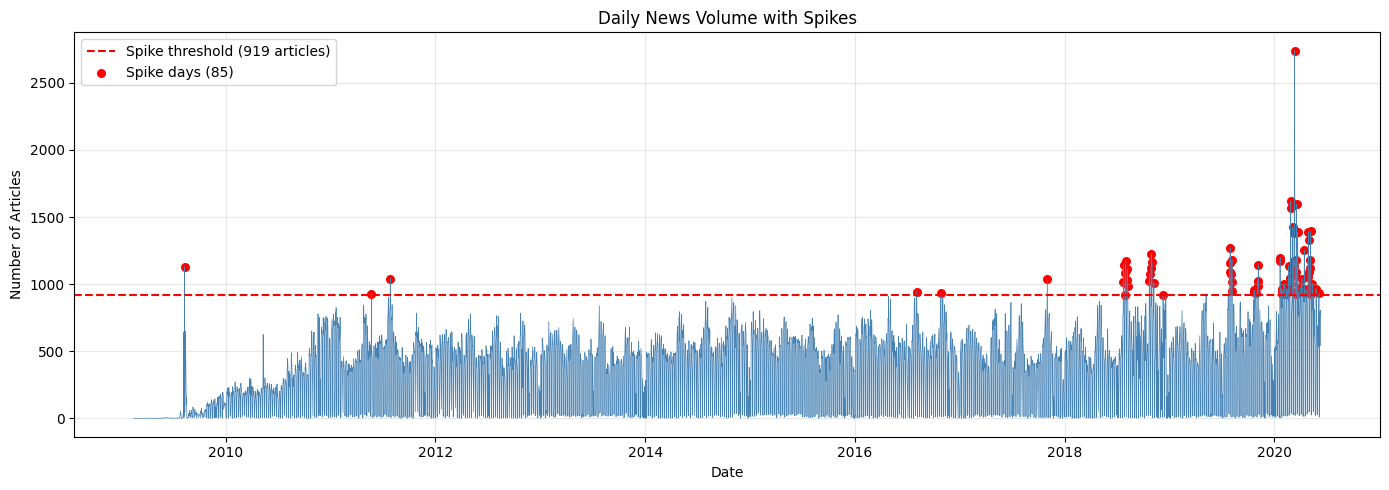

In [26]:
# Plot - Daily News Volume 
plt.figure(figsize=(14, 5))

# Time series
plt.plot(daily_volume.index, daily_volume.values, linewidth=0.5, color='steelblue')
plt.axhline(mean + 2*std, color='r', linestyle='--', label=f'Spike threshold ({mean + 2*std:.0f} articles)')
plt.scatter(spikes.index, spikes.values, color='red', s=30, label=f'Spike days ({len(spikes)})')
plt.xlabel('Date')
plt.ylabel('Number of Articles')
plt.title('Daily News Volume with Spikes')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [27]:
total_calendar_days = (df['date'].max() - df['date'].min()).days
days_with_news = df['date'].dt.date.nunique()
coverage_pct = (days_with_news / total_calendar_days) * 100

print(f"Days with news: {days_with_news:,} of {total_calendar_days:,} ({coverage_pct:.1f}%)")
print(f"Days without news: {total_calendar_days - days_with_news:,} ({100-coverage_pct:.1f}%)")

Days with news: 3,955 of 4,135 (95.6%)
Days without news: 180 (4.4%)


### Publication Date Trends

##### Data Coverage
- **Date range**: February 2009 – June 2020 (11+ years)
- **Days with news**: 3,955 of 4,135 (95.6%)
- **Days without news**: 180 (4.4% – weekends/holidays)
- **Average articles/day**: 356

##### News Volume Spikes
- **85 spike days** identified (2+ standard deviations above mean)
- **Largest spike**: 2,739 articles on March 12, 2020 (Black Thursday)
- **Top 5 spikes all in Feb–March 2020** (COVID crash period)

##### Key Insight
The dataset has strong daily coverage (95.6%). Extreme news spikes (2,739 vs. 356 average) coincide with major market stress events, making news volume a potential volatility indicator.

### Text Analysis (Topic Modeling) 

Get Most Common Words

In [32]:
# Sample headlines (use first 10k for speed)
headlines = df['headline'].fillna('').head(10000)

# Create word counter
vectorizer = CountVectorizer(max_features=20, stop_words='english')
X = vectorizer.fit_transform(headlines)

# Get most common words
words = vectorizer.get_feature_names_out()
counts = X.toarray().sum(axis=0)

word_freq = pd.DataFrame({'word': words, 'count': counts}).sort_values('count', ascending=False)
print("=== TOP 20 MOST COMMON WORDS ===")
print(word_freq)

=== TOP 20 MOST COMMON WORDS ===
         word  count
2       alcoa   1198
15     stocks   1158
18         vs   1071
9      market    924
8         est    898
7         eps    859
6    earnings    815
14     shares    758
12    reports    710
17     update    554
13      sales    538
0      abbvie    505
1     agilent    500
4        auto    486
3   announces    480
5         buy    477
11      price    471
16     target    470
19       week    464
10      parts    446


Get Most Distinctive Words

In [33]:
# TF-IDF vectorizer
tfidf = TfidfVectorizer(max_features=20, stop_words='english')
X_tfidf = tfidf.fit_transform(headlines)

# Get top TF-IDF words
words = tfidf.get_feature_names_out()
scores = X_tfidf.toarray().mean(axis=0)

tfidf_freq = pd.DataFrame({'word': words, 'tfidf_score': scores}).sort_values('tfidf_score', ascending=False)
print("\n=== TOP 20 TF-IDF WORDS (Most Distinctive) ===")
print(tfidf_freq)


=== TOP 20 TF-IDF WORDS (Most Distinctive) ===
         word  tfidf_score
15     stocks     0.095123
2       alcoa     0.092961
9      market     0.067649
6    earnings     0.064546
14     shares     0.055202
12    reports     0.041269
17     update     0.040430
18         vs     0.040222
3   announces     0.039721
0      abbvie     0.038944
7         eps     0.038199
19       week     0.036917
1     agilent     0.036841
5         buy     0.035004
8         est     0.031463
11      price     0.028686
4        auto     0.028394
16     target     0.028263
13      sales     0.028202
10      parts     0.025952


Get Bigrams (Two-Word Phrases)

In [34]:
# Find common two-word phrases
bigram_vectorizer = CountVectorizer(ngram_range=(2,2), max_features=20, stop_words='english')
X_bigram = bigram_vectorizer.fit_transform(headlines)

bigrams = bigram_vectorizer.get_feature_names_out()
bigram_counts = X_bigram.toarray().sum(axis=0)

bigram_freq = pd.DataFrame({'phrase': bigrams, 'count': bigram_counts}).sort_values('count', ascending=False)
print("\n=== TOP 20 COMMON PHRASES ===")
print(bigram_freq)


=== TOP 20 COMMON PHRASES ===
                     phrase  count
8                auto parts    437
15             price target    420
2              advance auto    406
4      agilent technologies    305
0                   52 week    302
17            stocks moving    256
1                   adj eps    243
5         american airlines    234
13                  mid day    207
6   applied optoelectronics    205
10       earnings scheduled    199
7                 atlas air    182
19           trading higher    182
18             stocks watch    179
14               pre market    178
12            market update    170
11       initiates coverage    170
3            advisory board    167
16                raises pt    166
9         companies trading    158


 Topic Modeling (Hidden Themes)

In [35]:
# Prepare data (need document-term matrix)
vectorizer_lda = CountVectorizer(max_features=1000, stop_words='english', max_df=0.95, min_df=2)
dtm = vectorizer_lda.fit_transform(headlines)

# Run LDA (5 topics)
lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(dtm)

# Display topics
def display_topics(model, feature_names, n_words=5):
    topics = {}
    for topic_idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-n_words-1:-1]]
        topics[f"Topic {topic_idx+1}"] = top_words
    return pd.DataFrame(topics)

feature_names = vectorizer_lda.get_feature_names_out()
topics_df = display_topics(lda, feature_names, n_words=6)
print("\n=== TOPICS DISCOVERED ===")
print(topics_df.to_string())


=== TOPICS DISCOVERED ===
   Topic 1 Topic 2   Topic 3   Topic 4  Topic 5
0   market    auto  earnings      says       vs
1   stocks   price     alcoa     alcoa      est
2      mid  target    shares     apple      eps
3  session     buy   trading       air    sales
4   moving   parts    higher  american  reports
5      day      pt   results       new      adj


#### Text Analysis - Key Findings

##### Dominant Themes
1. **Earnings Season** - eps, earnings, est, adj eps (most frequent theme)
2. **Analyst Actions** - price target, upgrade, downgrade
3. **Technical Levels** - 52 week, trading higher, pre market
4. **Event News** - announces, reports, scheduled